<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Hands_on_Activity_5_1_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 5.1: Clustering

#### Objective:

This activity aims to perform classification  of unlabeled data using K Means and Agglomerative Clustering

#### Intended Learning Outcomes (ILOs):
* Build the model using K Means and Agglomerative clustering.
* Determine the optimum number of clusters using elbow method.
* Visualize the dendogram produced by the agglomerative clustering


#### Resources:
* Jupyter Notebook
* Wholesale customers data.csv

#### Procedure:

We will used K-Means clustering to cluster the clients of a wholesale distributor based on their annual spending on diverse product categories, like milk, grocery, region, etc.


Import the needed libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans

Load the dataset and check the first five rows

In [ ]:
df=pd.read_csv("/content/Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Check the descriptive statistics of the dataset

In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Since K-Means is a distance-based algorithm, the difference between the magnitudes of the data will create a problem. Let us apply featuring scaling to standardize the data.

In [ ]:
# Use standard scaler to standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# statistics of scaled data
pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6,7
count,4.400000e+02,4.400000e+02,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,1.614870e-17,3.552714e-16,-3.431598e-17,0.000000,-4.037175e-17,3.633457e-17,2.422305e-17,-8.074349e-18
std,1.001138e+00,1.001138e+00,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-6.902971e-01,-1.995342e+00,-9.496831e-01,-0.778795,-8.373344e-01,-6.283430e-01,-6.044165e-01,-5.402644e-01
25%,-6.902971e-01,-7.023369e-01,-7.023339e-01,-0.578306,-6.108364e-01,-4.804306e-01,-5.511349e-01,-3.964005e-01
50%,-6.902971e-01,5.906683e-01,-2.767602e-01,-0.294258,-3.366684e-01,-3.188045e-01,-4.336004e-01,-1.985766e-01
75%,1.448652e+00,5.906683e-01,3.905226e-01,0.189092,2.849105e-01,9.946441e-02,2.184822e-01,1.048598e-01
max,1.448652e+00,5.906683e-01,7.927738e+00,9.183650,8.936528e+00,1.191900e+01,7.967672e+00,1.647845e+01


Build the K-Means model

In [ ]:
# Create cluster of 2
kmeans = KMeans(n_clusters=2, init='k-means++')

# fit the k means algorithm on scaled data
kmeans.fit(data_scaled)

KMeans(n_clusters=2)

 Calculate the inertia to evaluate how well the formed clusters are.

In [ ]:
# inertia on the fitted data
kmeans.inertia_

2599.3855593561398

Interpret the result of the inertia

<font color= green> The `inertia`  value represent the total, within-cluster variation for this 2-cluster model.It gives us the single number  that represent the spread out of the datapoint  within their clusters.By using the interia we can group our clients together based on their spending patterns on a given products. By analyzing the inertia we can gain valuable insights by identifying spending pattern and customer segment of our data.

Use the elbow curve to determine the optimum number of clusters in Python.



Text(0, 0.5, 'Inertia')

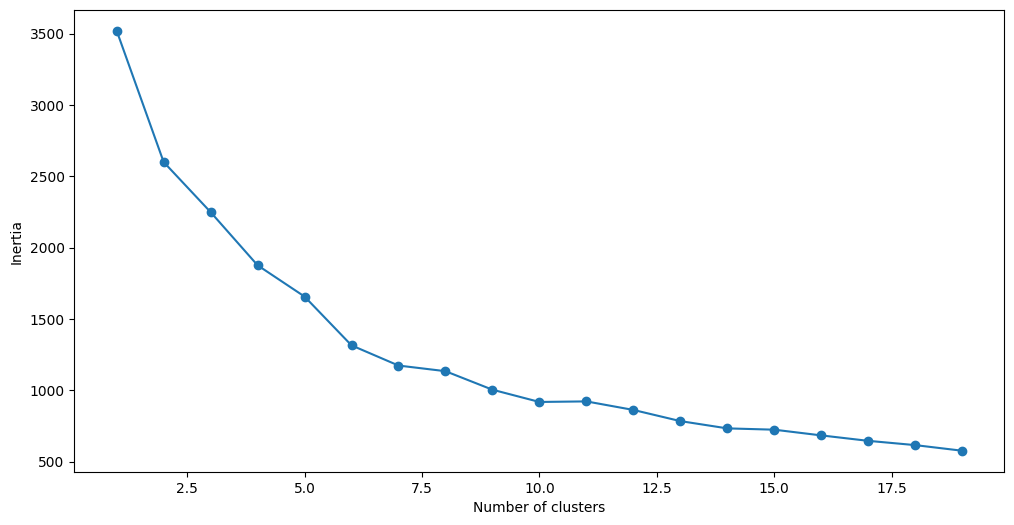

In [ ]:
# fitting multiple k-means algorithms and storing the values in an empty list
SSE = []
for cluster in range(1,20):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(data_scaled)
    SSE.append(kmeans.inertia_)

# converting the results into a dataframe and plotting them
frame = pd.DataFrame({'Cluster':range(1,20), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

Interpret the result of the elbow curve.

<font color = green> The elbow method we do in this activity  determines the optimal number of cluster  of K-means by visualizing the relationship between the number of the cluster and within-cluster sum of squares(inertia). The plot show the number of cluster on the x-axis  na dthe inertia on y-axis. The elbow point  of our curve represent the optimal number of cluster. In our case, the elbows  we got is around  5 or 6 clusters, suggesting  that using  5 or 6 would provide a good  balance  between minimizing inertia and avoid overfitting the data.

Build a model using 5 clusters and k-means ++ initialization

In [ ]:
# k means using 5 clusters and k-means++ initialization
kmeans = KMeans(n_clusters = 5, init='k-means++')
kmeans.fit(data_scaled)
pred = kmeans.predict(data_scaled)

In [ ]:
frame = pd.DataFrame(data_scaled)
frame['cluster'] = pred
frame['cluster'].value_counts()

,count
cluster,
1,211
0,125
3,92
4,11
2,1


There are 208 data points belonging to cluster 1 (index 1), then 125 points in cluster 2 (index 2), and so on.

Compute the centroids of the K means cluster

In [ ]:
centroids = kmeans.cluster_centers_
print(centroids)

[[ 1.44865163e+00  1.66562579e-01 -3.26341681e-01  4.22850268e-01
   6.59619766e-01 -3.57310160e-01  6.86224579e-01  4.36563167e-03]
 [-6.80159888e-01  5.90668285e-01  1.49701883e-01 -3.38970651e-01
  -4.35787592e-01  8.62596306e-02 -4.39578802e-01 -7.92402039e-02]
 [-6.90297086e-01  5.90668285e-01  1.96681731e+00  5.17550306e+00
   1.28721685e+00  6.90059988e+00 -5.54861977e-01  1.64784475e+01]
 [-5.74049873e-01 -1.58776439e+00  3.22040971e-02 -3.24809935e-01
  -3.91593636e-01  2.08356115e-01 -4.23471344e-01 -1.15896320e-01]
 [ 1.44865163e+00  2.93864819e-03  3.88728973e-01  3.94304862e+00
   4.02164626e+00  3.57841274e-02  4.22611641e+00  9.41635735e-01]]


What is the purpose of the centroids?

<font color = green> The centroids serve as our central point for each cluster. The purpose of  centroids is to define the locationand characteristics of clusters. Each centroids acts as representative for all datapoints assigned to its cluster. It is the average datapoint within the cluster.during the process, datapoints  are  assigned  to the nearest centroids based on distance  that forms a distincts clusters around the centroids. The value of centroid's features provide insights into the typical characteristics of data points whitin its cluster by examining the value of centroids we can understand the central tendencies and patterns within each group.

Fit an agglomerative clustering model with two clusters.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

ag = AgglomerativeClustering(n_clusters=2, linkage='ward', compute_full_tree=True)
ag = ag.fit(data_scaled)
df['agglom'] = ag.fit_predict(data_scaled)

Visualize the dendrogram produced by agglomerative clustering

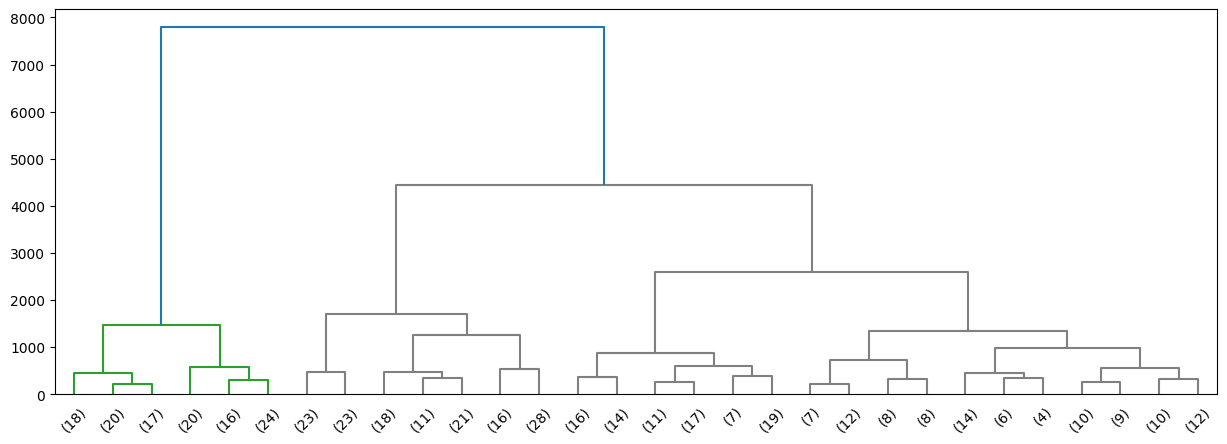

In [ ]:
from scipy.cluster import hierarchy
from matplotlib import colors
import seaborn as sns

Z = hierarchy.linkage(ag.children_, method='ward')

fig, ax = plt.subplots(figsize=(15,5))

# Some color customization
dark_palette = sns.color_palette()
red = colors.to_hex(dark_palette[2])
blue = colors.to_hex(dark_palette[0])

hierarchy.set_link_color_palette([red, 'gray'])

den = hierarchy.dendrogram(Z, orientation='top',
                           p=30, truncate_mode='lastp',
                           show_leaf_counts=True, ax=ax,
                           above_threshold_color=blue)

Interpret the result of the dendogram

<font color = green> Dendogram are tree- like diagram which illustrates the arrangement of clusters produce by hierarchical clustering. Our dendogram shows 2 primary cluster that based on the ward linkage method and  the distance metric we used. Within our major cluster we have branches for subclusters  which represent a finer groupings of datapoints within  the main clusters. The height of the link connected to our clusters represent the dissimilarity between.Thus, cluster  connected by the shorter links are more similar while connected by longer link are more dissimilar. We can also cut the dendogram at different height to obtain diferent number of cluster. In our dendogram we use ward linkages to minimize the variance within the cluster. Our dendogram also show the clear separation  between two amjor cluster  which suggest a significant difference between those groups. The subcluster of each major cluster provide more granularity for understanding the data.

Supplementary Activity:
* Choose your own dataset.
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Standardize the variables.
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Use k-means clustering to identify the groups of the dataset.
* Use 1 to 10 clusters
* Determine the optimum number of clusters
* Use agglomerative clustering and visualize the dendogram
* Compare the results obtained by the K means and agglomerative clustering.

## Dataset Information
ICMR wants to analyze different types of cancers, such as breast cancer, renal cancer, colon cancer, lung cancer, and prostate cancer becoming a cause of worry in recent years. They would like to identify the probable cause of these cancers in terms of genes responsible for each cancer type. This would lead us to early identification of each type of cancer reducing the fatality rate.

Dataset Details:
The input dataset contains 802 samples for the corresponding 802 people who have been detected with different types of cancer. Each sample contains expression values of more than 20K genes. Samples have one of the types of tumours: BRCA, KIRC, COAD, LUAD, and PRAD.

[ICMR dataset](https://www.kaggle.com/code/madhuraatmarambhagat/icmr-cancer-genes-analysis-pca-k-means-clust/)



## **Upload the dataset**

Import necessary library and packages

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv("/content/data.csv")
data.head()

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


## **Determine the number of datapoints columns and data types**

In [ ]:
# Determine the number of datapoints columns and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20532 entries, Unnamed: 0 to gene_20530
dtypes: float64(20531), object(1)
memory usage: 125.5+ MB


##**Remove unneccesary columns**

In [ ]:
# Remove unneccesary columns
data=data.drop(["Unnamed: 0"],axis=1)
data=data.drop(["gene_5"],axis=1)
data.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_6,gene_7,gene_8,gene_9,gene_10,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,0.0,2.017209,3.265527,5.478487,10.431999,7.175175,0.591871,0.0,0.0,0.591871,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,0.0,0.592732,1.588421,7.586157,9.623011,6.816049,0.000000,0.0,0.0,0.000000,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,0.0,3.511759,4.327199,6.881787,9.870730,6.972130,0.452595,0.0,0.0,0.000000,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,0.0,3.663618,4.507649,6.659068,10.196184,7.843375,0.434882,0.0,0.0,0.000000,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,0.0,2.655741,2.821547,6.539454,9.738265,6.566967,0.360982,0.0,0.0,0.000000,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


##**Do data cleaning such as removing empty values(NaN), replacing missing data .**

In [ ]:
data.isnull().sum()

,0
gene_0,0
gene_1,0
gene_2,0
gene_3,0
gene_4,0
...,...
gene_20526,0
gene_20527,0
gene_20528,0
gene_20529,0


In [ ]:
# Remove null and values
data=data.dropna()

In [ ]:
data.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_6,gene_7,gene_8,gene_9,gene_10,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,0.0,2.017209,3.265527,5.478487,10.431999,7.175175,0.591871,0.0,0.0,0.591871,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,0.0,0.592732,1.588421,7.586157,9.623011,6.816049,0.000000,0.0,0.0,0.000000,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,0.0,3.511759,4.327199,6.881787,9.870730,6.972130,0.452595,0.0,0.0,0.000000,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,0.0,3.663618,4.507649,6.659068,10.196184,7.843375,0.434882,0.0,0.0,0.000000,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,0.0,2.655741,2.821547,6.539454,9.738265,6.566967,0.360982,0.0,0.0,0.000000,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


##**Standardize the variables.**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
data_scaled

array([[-0.19479935, -0.82802988,  0.15980044, ..., -1.18793812,
        -0.11648251, -0.26190144],
       [-0.19479935, -2.01501735, -1.415042  , ..., -0.34227662,
        -1.65688871, -0.26190144],
       [-0.19479935,  0.41734754,  1.15673547, ...,  0.88686027,
        -1.85526414, -0.26190144],
       ...,
       [-0.19479935,  0.19888076,  0.57481583, ..., -0.22008186,
        -0.41046699,  1.3485582 ],
       [-0.19479935, -0.35045311, -0.28863152, ...,  1.43719268,
         0.09195083, -0.26190144],
       [-0.19479935, -0.57135218,  0.66725377, ...,  0.45087581,
        -0.47161901, -0.26190144]])

## **Perform descriptive statistics such as mean, median and mode**

In [ ]:
data.describe()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_6,gene_7,gene_8,gene_9,gene_10,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,...,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,0.026642,3.010909,3.095350,6.722305,9.813612,7.405509,0.499882,0.016744,0.013428,0.688177,...,5.896573,8.765891,10.056252,4.847727,9.741987,11.742228,10.155271,9.590726,5.528177,0.095411
std,0.136850,1.200828,1.065601,0.638819,0.506537,1.108237,0.508799,0.133635,0.204722,1.173568,...,0.746399,0.603176,0.379278,2.382728,0.533898,0.670371,0.580569,0.563849,2.073859,0.364529
min,0.000000,0.000000,0.000000,5.009284,8.435999,3.930747,0.000000,0.000000,0.000000,0.000000,...,2.853517,6.678368,8.669456,0.000000,7.974942,9.045255,7.530141,7.864533,0.593975,0.000000
25%,0.000000,2.299039,2.390365,6.303346,9.464466,6.676042,0.000000,0.000000,0.000000,0.000000,...,5.454926,8.383834,9.826027,3.130750,9.400747,11.315857,9.836525,9.244219,4.092385,0.000000
50%,0.000000,3.143687,3.127006,6.655893,9.791599,7.450114,0.443076,0.000000,0.000000,0.360196,...,5.972582,8.784144,10.066385,5.444935,9.784524,11.749802,10.191207,9.566511,5.218618,0.000000
75%,0.000000,3.883484,3.802534,7.038447,10.142324,8.121984,0.789354,0.000000,0.000000,0.903887,...,6.411292,9.147136,10.299025,6.637412,10.082269,12.177852,10.578561,9.917888,6.876382,0.000000
max,1.482332,6.237034,6.063484,10.129528,11.355621,10.718190,2.779008,1.785592,4.067604,12.293023,...,7.771054,11.105431,11.318243,9.207495,11.811632,13.715361,11.675653,12.813320,11.205836,5.254133


In [ ]:
pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,...,20520,20521,20522,20523,20524,20525,20526,20527,20528,20529
count,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,...,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02,8.010000e+02
mean,-7.761859e-18,-2.882976e-17,5.211534e-16,9.979533e-17,-1.729786e-16,-3.370864e-16,5.544185e-17,1.219721e-17,-6.653022e-18,-1.286251e-16,...,-1.131014e-15,-7.362678e-16,-2.388435e-15,5.100650e-17,1.676562e-15,-1.786336e-15,8.759812e-16,2.749916e-16,-2.672297e-16,2.217674e-18
std,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,...,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00,1.000625e+00
min,-1.947993e-01,-2.508929e+00,-2.906607e+00,-2.683220e+00,-2.721366e+00,-3.137355e+00,-9.830880e-01,-1.253755e-01,-6.563299e-02,-5.867636e-01,...,-4.079532e+00,-3.463046e+00,-3.658700e+00,-2.035799e+00,-3.311774e+00,-4.025621e+00,-4.524475e+00,-3.063356e+00,-2.380723e+00,-2.619014e-01
25%,-1.947993e-01,-5.931866e-01,-6.619973e-01,-6.562442e-01,-6.897104e-01,-6.586345e-01,-9.830880e-01,-1.253755e-01,-6.563299e-02,-5.867636e-01,...,-5.920735e-01,-6.338043e-01,-6.073885e-01,-7.210434e-01,-6.395484e-01,-6.364197e-01,-5.493656e-01,-6.149231e-01,-6.927610e-01,-2.619014e-01
50%,-1.947993e-01,1.106410e-01,2.972590e-02,-1.040266e-01,-4.348466e-02,4.027376e-02,-1.117158e-01,-1.253755e-01,-6.563299e-02,-2.796482e-01,...,1.018984e-01,3.028065e-02,2.673326e-02,2.507971e-01,7.972069e-02,1.130606e-02,6.193737e-02,-4.297362e-02,-1.493600e-01,-2.619014e-01
75%,-1.947993e-01,7.270983e-01,6.640633e-01,4.951942e-01,6.493447e-01,6.469035e-01,5.692881e-01,-1.253755e-01,-6.563299e-02,1.839216e-01,...,6.900345e-01,6.324578e-01,6.404919e-01,7.515766e-01,6.377510e-01,6.502323e-01,7.295516e-01,5.805917e-01,6.505011e-01,-2.619014e-01
max,1.064381e+01,2.688263e+00,2.787148e+00,5.336962e+00,3.046117e+00,2.991012e+00,4.482225e+00,1.324467e+01,1.981568e+01,9.894695e+00,...,2.512935e+00,3.881123e+00,3.329434e+00,1.830881e+00,3.878901e+00,2.945186e+00,2.620415e+00,5.718915e+00,2.739437e+00,1.416059e+01


##**Perform data visualization**


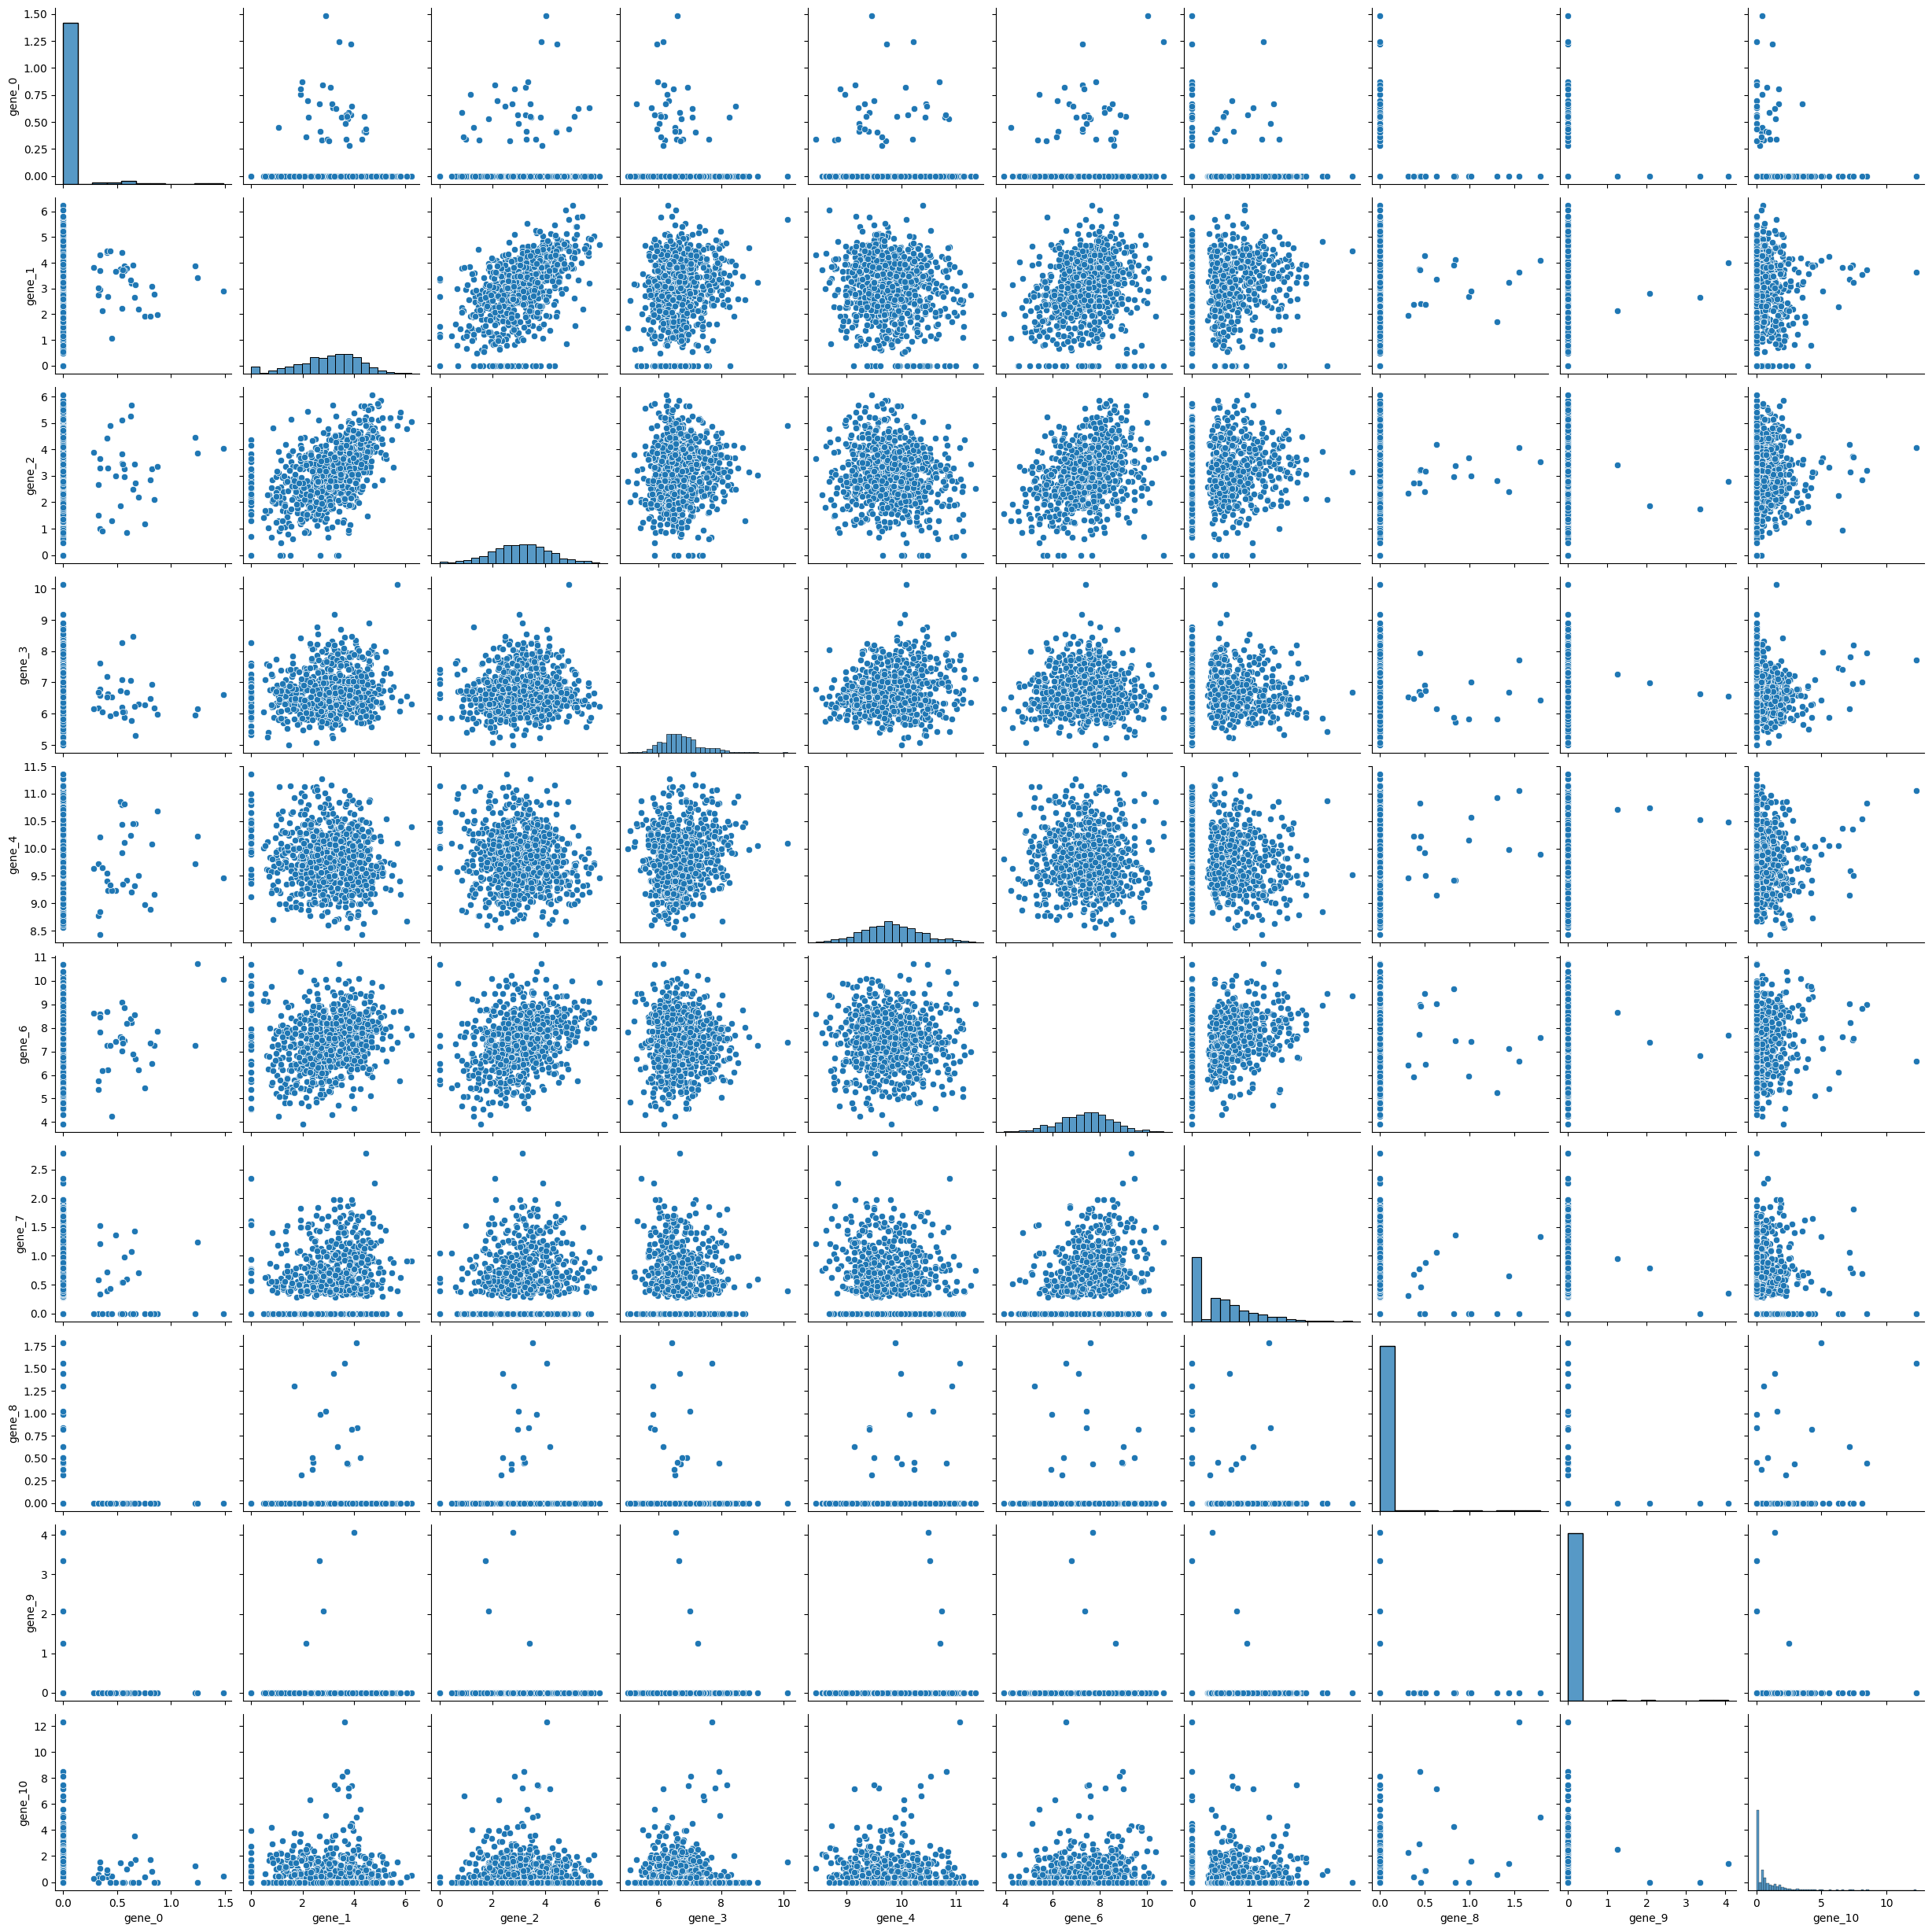

In [ ]:
# make a pairplot for genes 0 to 10
sns.pairplot(data.iloc[:,0:10])

## **Use k-means clustering to identify the groups of the dataset.**

In [ ]:
# Create cluster of 2
kmeans = KMeans(n_clusters=2, init='k-means++')

# fit the k means algorithm on scaled data
kmeans.fit(data_scaled)

KMeans(n_clusters=2)

In [ ]:
# inertia on the fitted data
kmeans.inertia_

14820905.64060529

Text(0, 0.5, 'Inertia')

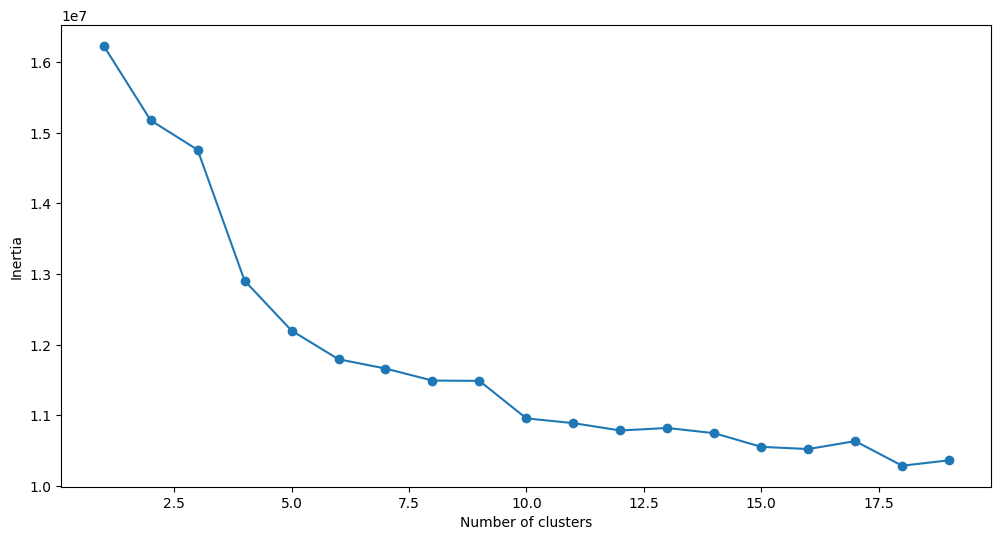

In [ ]:
# fitting multiple k-means algorithms and storing the values in an empty list
SSE = []
for cluster in range(1,20):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(data_scaled)
    SSE.append(kmeans.inertia_)

# converting the results into a dataframe and plotting them
frame = pd.DataFrame({'Cluster':range(1,20), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

##**Use 1 to 10 clusters**


In [ ]:
# k means using 5 clusters and k-means++ initialization
kmeans = KMeans(n_clusters = 10, init='k-means++')
kmeans.fit(data_scaled)
pred = kmeans.predict(data_scaled)

In [ ]:
frame = pd.DataFrame(data_scaled)
frame['cluster'] = pred
frame['cluster'].value_counts()

,count
cluster,
2,227
8,133
6,124
9,93
3,74
0,49
5,38
7,34
4,18


In [ ]:
centroids = kmeans.cluster_centers_
print(centroids)

[[-0.11306378  0.35111451  0.09553286 ...  0.87502156  0.04654883
   0.33172137]
 [-0.19479935 -0.74069121 -0.72152841 ... -0.15228127 -0.72771605
  -0.11532825]
 [-0.15039898 -0.07440325 -0.32783214 ...  0.45538735  0.3722777
  -0.14478598]
 ...
 [ 0.21492873 -0.50228863 -0.35356974 ... -0.83625667 -0.09455624
  -0.00925943]
 [ 0.12370309  0.36023251  0.41839998 ... -0.4133004  -0.05321061
   0.27716126]
 [ 0.18967937 -0.46787477 -0.70409177 ... -0.06784429 -0.30847557
  -0.06465001]]


##**Determine the optimum number of clusters**

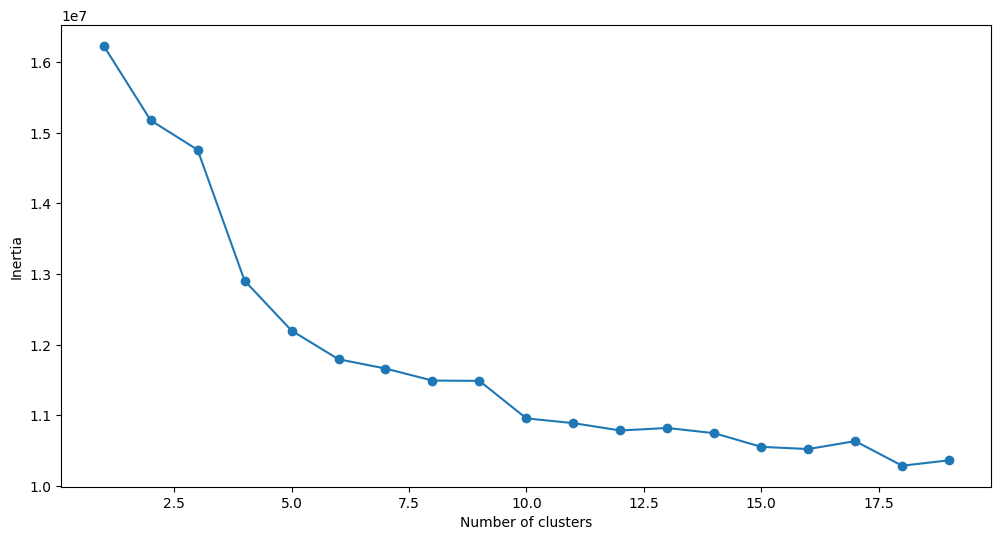

In [ ]:
frame = pd.DataFrame({'Cluster': range(1, 20), 'SSE': SSE})  # Create a DataFrame
plt.figure(figsize=(12, 6))  # Set figure size
plt.plot(frame['Cluster'], frame['SSE'], marker='o')  # Plot the elbow curve
plt.xlabel('Number of clusters')  # Set x-axis label
plt.ylabel('Inertia')  # Set y-axis label
plt.show()  # Display the plot

<font color = green> based on the our elbow point the optimum number of cluster is around 10 cluster.

##**Use agglomerative clustering and visualize the dendogram**

In [ ]:
from sklearn.cluster import AgglomerativeClustering

ag = AgglomerativeClustering(n_clusters=2, linkage='ward', compute_full_tree=True)
ag = ag.fit(data_scaled)
data['agglom'] = ag.fit_predict(data_scaled)

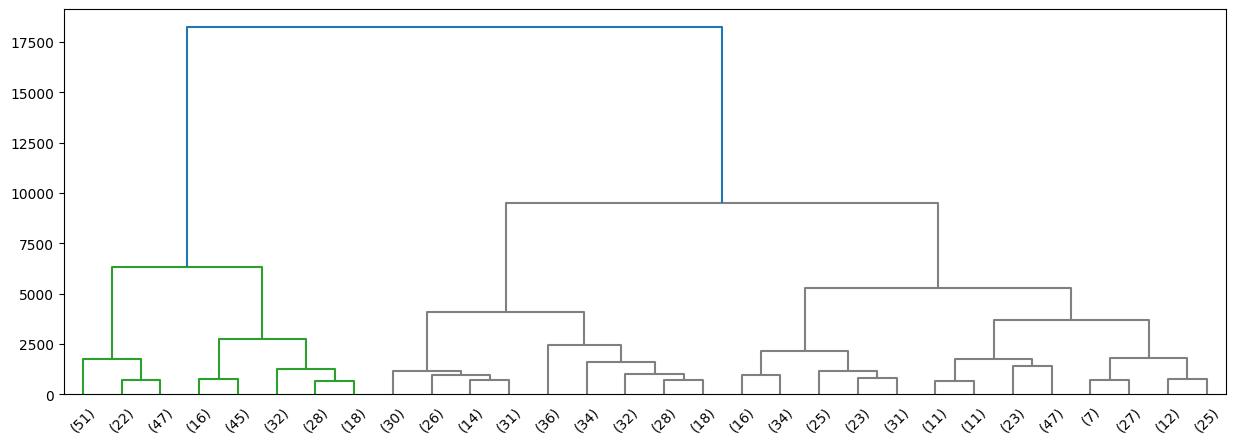

In [ ]:
from scipy.cluster import hierarchy
from matplotlib import colors
import seaborn as sns

Z = hierarchy.linkage(ag.children_, method='ward')

fig, ax = plt.subplots(figsize=(15,5))

# Some color customization
dark_palette = sns.color_palette()
red = colors.to_hex(dark_palette[2])
blue = colors.to_hex(dark_palette[0])

hierarchy.set_link_color_palette([red, 'gray'])

den = hierarchy.dendrogram(Z, orientation='top',
                           p=30, truncate_mode='lastp',
                           show_leaf_counts=True, ax=ax,
                           above_threshold_color=blue)

##**Compare the results obtained by the K means and agglomerative clustering.**

<font color = green> Based on our findings in our dataset, we found out that the elbow method suggest that the optimal number of cluster is around 10. Thus, K-means partition the data into distinct cluster based on te minimizing the within-cluster variance. The centroids represent the average of our cluster  datapoint does provide an insights for the characteristic of each group. In agglomerative clustering  the ward  linkage is use to minimize the variance. In Comaprison, K-mean identified  an optinal muber of cluster around 10.Both methods revealed distinct clusters within the dataset. K-means focused on determining the optimal number of clusters based on the elbow method and provides detailed characteristics of each cluster through its centroids. Agglomerative clustering created a hierarchy of clusters, allowing for examination at different levels and illustrating cluster relationships through its dendrogram. The choice between the two methods depends on the specific goals and preferences for interpretability and computational efficiency.

#### Conclusion

Okay, here's a conclusion for the activity based on the analysis and comparison of K-means and Agglomerative clustering:

Conclusion

In this activity, we explored two popular clustering techniques, K-means and Agglomerative clustering, to analyze and group data points based on their inherent similarities. Both methods were applied to datasets related to wholesale customer spending and cancer gene expression.

K-means clustering effectively partitioned the data into distinct clusters based on minimizing within-cluster variance. The elbow method helped determine the optimal number of clusters, providing valuable insights into the underlying structure of the data. The centroids of the clusters offered a representative profile of the data points within each group.

Agglomerative clustering provided a hierarchical perspective on the data, building a dendrogram that visualized the relationships between clusters at different levels of granularity. The 'ward' linkage method ensured that clusters were formed by minimizing variance within groups, similar to K-means.

The comparison of both methods revealed their strengths and differences. K-means focused on finding the optimal number of clusters and provided detailed characteristics through its centroids. Agglomerative clustering offered a hierarchical view, enhancing interpretability through the dendrogram.

Overall, both K-means and Agglomerative clustering proved valuable for identifying patterns and groupings within the datasets. The choice between the two methods depends on the specific analytical goals and preferences for interpretability, computational efficiency, and cluster structure.